# SPX TP2/RR2 results

## What this notebook does

This notebook recreates the main tables and figures from Chapter 3 using the
saved SPX result files. It covers:

1. yearly and rolling TP2/RR2 violation rates;
2. where violations occur by maturity and moneyness;
3. whether midpoint violations survive the bid-ask spread;
4. ordinary calendar-monotonicity failures; and
5. how long a violation remains observable.

For two maturities and two forward-moneyness levels, let (A) be the product
of the two original option prices and (B) the product formed after swapping
the moneyness levels across maturities. A call TP2 violation has (A<B), while
a put RR2 violation has (A>B). The full construction is in `src/spx.py`.

## Run guide

**This is a lightweight notebook and it is safe to use `Run All`.** It only
reads compact CSVs from `outputs/spx` and saves figures in `figures`. It does
not read the annual OptionMetrics quote files and it does not change the saved
results.

The heavy calculation is the separate `python -m src.spx ...` run described in
the repository README. That run tests every usable SPX surface from 2000 to
2025 and can take several hours. It is not called anywhere in this notebook.


## 1. Setup

Start Jupyter from the `notebooks` folder as described in the README. The two
paths below then mean:

- `OUT`: the saved Chapter 3 CSV tables;
- `FIGURES`: the folder where this notebook writes PNG figures.

The remaining imports are only used to make tables and plots.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl


OUT = Path("../outputs/spx")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

# Show enough columns for the compact result tables below.
pl.Config.set_tbl_cols(20)


## 2. Load the saved results

The CSVs fall into four groups:

- `coverage`, `annual` and `rolling` describe the sample and violation rates;
- `maturity` and `moneyness` locate violations on the option surface;
- `paper_checks`, `quote_quality` and `violation_quality` compare midpoint and
  bid-ask tests and describe the quotes involved;
- `calendar`, `duration`, `persistence` and `gap_outcomes` describe competing
  calendar failures and the later path of each violation episode.

These are already aggregated outputs. Loading them is quick and does not
repeat the quote-level tests.


In [2]:
# Sample size and violation rates.
coverage = pl.read_csv(OUT / "data_coverage_by_year.csv", try_parse_dates=True)
annual = pl.read_csv(OUT / "overall_by_year.csv")
rolling = pl.read_csv(OUT / "rolling_30_day_rates.csv", try_parse_dates=True)

# Location of violations on the surface.
maturity = pl.read_csv(OUT / "maturity_violation_rates.csv")
moneyness = pl.read_csv(OUT / "moneyness_violation_rates.csv")

# Midpoint, bid-ask and quote-quality checks.
paper_checks = pl.read_csv(OUT / "paper_checks_overall.csv")
paper_checks_year = pl.read_csv(OUT / "paper_checks_by_year.csv")
quote_quality = pl.read_csv(OUT / "quote_quality_summary.csv")
violation_quality = pl.read_csv(OUT / "violation_spread_summary.csv")

# Calendar and duration results.
calendar = pl.read_csv(OUT / "calendar_monotonicity_check.csv")
calendar_year = pl.read_csv(OUT / "calendar_monotonicity_check_by_year.csv")
calendar_moneyness = pl.read_csv(OUT / "calendar_monotonicity_by_moneyness.csv")
duration = pl.read_csv(OUT / "duration_final_outcomes.csv")
duration_distribution = pl.read_csv(OUT / "duration_distribution.csv")
persistence = pl.read_csv(OUT / "persistence_curve.csv")
gap_outcomes = pl.read_csv(OUT / "gap_outcomes.csv")

print("Saved SPX result tables loaded.")


Saved SPX result tables loaded.


## 3. Main violation rates

`coverage` first shows which dates and years are present. The next table pools
the underlying pair counts over three samples rather than averaging annual
percentages. A violation rate is therefore

\[
\text{violation rate}
=\frac{\text{number of violated comparisons}}
       {\text{number of tested comparisons}}.
\]

The 2000-2022 row matches the paper period. The 2023-2025 row is the holdout,
with 2025 ending on 29 August.


In [3]:
def summarise_period(label, first_year, last_year):
    # Pool the tested pairs and violations over a chosen set of years.

    selected = annual.filter(pl.col("year").is_between(first_year, last_year))

    call_tests = selected["call_pairs_tested"].sum()
    put_tests = selected["put_pairs_tested"].sum()
    call_violations = selected["call_violations"].sum()
    put_violations = selected["put_violations"].sum()

    return {
        "sample": label,
        "call_pairs_tested": call_tests,
        "call_violations": call_violations,
        "call_violation_rate": call_violations / call_tests,
        "put_pairs_tested": put_tests,
        "put_violations": put_violations,
        "put_violation_rate": put_violations / put_tests,
    }


periods = pl.DataFrame([
    summarise_period("2000-2022", 2000, 2022),
    summarise_period("2023-2025", 2023, 2025),
    summarise_period("Full sample", 2000, 2025),
]).with_columns(
    (100 * pl.col("call_violation_rate")).round(3).alias("call_percent"),
    (100 * pl.col("put_violation_rate")).round(3).alias("put_percent"),
)

display(coverage)
display(periods)


year,file,file_size_mb,first_date,last_date,number_of_dates,has_am_settlement_column,has_delta_column
i64,str,f64,date,date,i64,bool,bool
2000,"""optionMetricsSpx2000.csv""",21.041719,2000-01-03,2000-12-29,252,true,true
2001,"""optionMetricsSpx2001.csv""",20.213353,2001-01-02,2001-12-31,248,true,true
2002,"""optionMetricsSpx2002.csv""",21.335897,2002-01-02,2002-12-31,252,true,true
2003,"""optionMetricsSpx2003.csv""",20.994309,2003-01-02,2003-12-31,252,true,true
2004,"""optionMetricsSpx2004.csv""",22.3017,2004-01-02,2004-12-31,252,true,true
…,…,…,…,…,…,…,…
2021,"""optionMetricsSpx2021.csv""",863.196026,2021-01-04,2021-12-31,252,true,true
2022,"""optionMetricsSpx2022.csv""",839.265808,2022-01-03,2022-12-30,251,true,true
2023,"""optionMetricsSpx2023.csv""",806.537815,2023-01-03,2023-12-29,250,true,true


sample,call_pairs_tested,call_violations,call_violation_rate,put_pairs_tested,put_violations,put_violation_rate,call_percent,put_percent
str,i64,i64,f64,i64,i64,f64,f64,f64
"""2000-2022""",737346076,1702501,0.002309,1554542793,7989403,0.005139,0.231,0.514
"""2023-2025""",747521156,237507,0.000318,1569969325,28770482,0.018326,0.032,1.833
"""Full sample""",1484867232,1940008,0.001307,3124512118,36759885,0.011765,0.131,1.176


### Annual rates

Each point below pools all valid comparisons within one calendar year. This
shows whether the full-sample rate is stable or driven by particular periods.


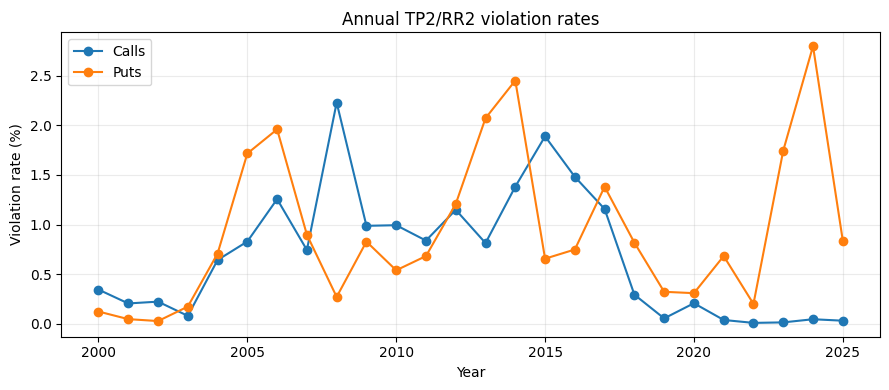

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    annual["year"],
    100 * annual["call_violation_rate"],
    marker="o",
    label="Calls",
)
ax.plot(
    annual["year"],
    100 * annual["put_violation_rate"],
    marker="o",
    label="Puts",
)

ax.set(
    xlabel="Year",
    ylabel="Violation rate (%)",
    title="Annual TP2/RR2 violation rates",
)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "annual_violation_rates.png", dpi=150)
plt.show()


### Rolling rates

The annual plot can hide shorter episodes. The next figure pools the previous
30 trading days at each date. It is more variable because each observation
uses a much smaller window.


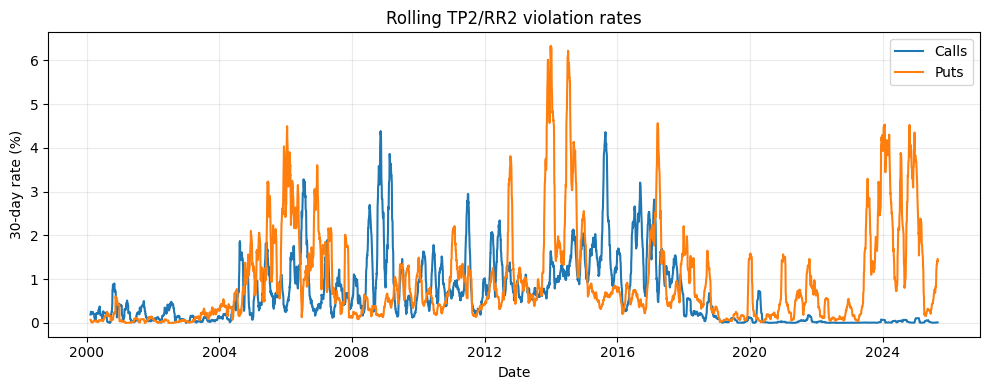

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(rolling["date"], 100 * rolling["call_rate_30d"], label="Calls")
ax.plot(rolling["date"], 100 * rolling["put_rate_30d"], label="Puts")

ax.set(
    xlabel="Date",
    ylabel="30-day rate (%)",
    title="Rolling TP2/RR2 violation rates",
)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "daily_rolling_violation_rates.png", dpi=150)
plt.show()


## 4. Maturity and moneyness

The next results show where violations occur on the option surface.

- `T1` is the shorter maturity and `T2` is the longer maturity.
- `both_itm` means both forward-moneyness points are in the money.
- `both_otm` means both are out of the money.
- `crosses_forward` means the two points lie on opposite sides of the forward.

The maturity table reports the share of all violations in short-maturity and
small-maturity-gap buckets. These are shares of violations, not violation
rates among all tested pairs.


In [6]:
# Calculate each share separately for calls and puts.
maturity_summary = (
    maturity
    .group_by("cp_flag")
    .agg(
        (100 * pl.when(pl.col("T1_week_start") <= 28)
         .then(pl.col("violations")).otherwise(0).sum()
         / pl.col("violations").sum())
        .round(2).alias("short_maturity_within_28_days_percent"),

        (100 * pl.when(pl.col("T1_week_start") <= 56)
         .then(pl.col("violations")).otherwise(0).sum()
         / pl.col("violations").sum())
        .round(2).alias("short_maturity_within_56_days_percent"),

        (100 * pl.when(
            (pl.col("T2_week_start") - pl.col("T1_week_start")) <= 28
         ).then(pl.col("violations")).otherwise(0).sum()
         / pl.col("violations").sum())
        .round(2).alias("maturity_gap_within_28_days_percent"),

        (100 * pl.when(
            (pl.col("T2_week_start") - pl.col("T1_week_start")) <= 56
         ).then(pl.col("violations")).otherwise(0).sum()
         / pl.col("violations").sum())
        .round(2).alias("maturity_gap_within_56_days_percent"),
    )
    .sort("cp_flag")
)

display(maturity_summary)
display(moneyness)


cp_flag,short_maturity_within_28_days_percent,short_maturity_within_56_days_percent,maturity_gap_within_28_days_percent,maturity_gap_within_56_days_percent
str,f64,f64,f64,f64
"""C""",81.08,97.66,73.58,92.08
"""P""",95.52,99.37,81.67,94.44


cp_flag,moneyness_region,pairs_tested,violations,violation_rate
str,str,i64,i64,f64
"""C""","""both_itm""",228891523,9862,0.000043
"""C""","""both_otm""",626393131,1892581,0.003021
"""C""","""crosses_forward""",629582578,37565,0.00006
"""P""","""both_itm""",142333522,34022,0.000239
"""P""","""both_otm""",2141441597,36655812,0.017117
"""P""","""crosses_forward""",840736999,70051,0.000083


The table above gives the exact moneyness counts. The bar chart below compares
the corresponding violation rates. The denominator for each bar is the
number of valid tests in that moneyness region.


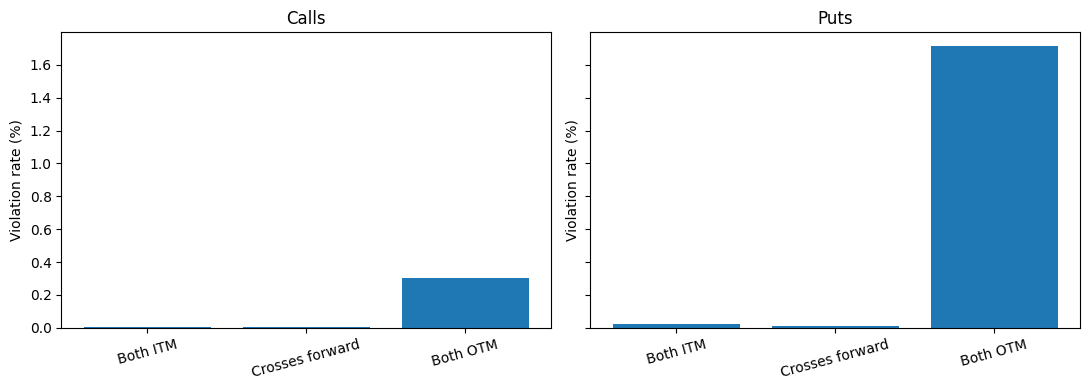

In [7]:
moneyness_order = ["both_itm", "crosses_forward", "both_otm"]
moneyness_labels = ["Both ITM", "Crosses forward", "Both OTM"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, option_type, title in zip(axes, ["C", "P"], ["Calls", "Puts"]):
    rows = moneyness.filter(pl.col("cp_flag") == option_type)
    rates = [
        100 * rows.filter(pl.col("moneyness_region") == region)["violation_rate"][0]
        for region in moneyness_order
    ]

    ax.bar(moneyness_labels, rates)
    ax.set(title=title, ylabel="Violation rate (%)")
    ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(FIGURES / "moneyness_violation_rates.png", dpi=150)
plt.show()


### Maturity heatmap

Each heatmap cell is the violation rate for one weekly `T1` and `T2` bucket.
The display is restricted to `T1 <= 84` days and `T2 <= 180` days so the dense
short-dated part of the surface remains readable. Blank cells had no valid
comparison.


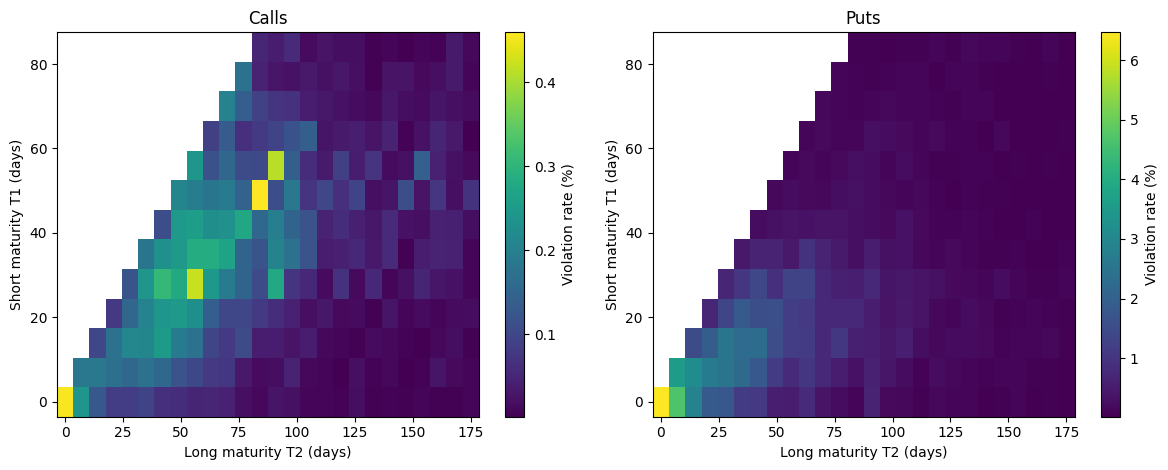

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, option_type, title in zip(axes, ["C", "P"], ["Calls", "Puts"]):
    rows = maturity.filter(
        (pl.col("cp_flag") == option_type)
        & (pl.col("T1_week_start") <= 84)
        & (pl.col("T2_week_start") <= 180)
    )

    # Turn the long-maturity buckets into columns for imshow.
    grid = (
        rows
        .pivot(
            values="violation_rate",
            index="T1_week_start",
            on="T2_week_start",
            aggregate_function="first",
        )
        .sort("T1_week_start")
    )

    x_values = np.array([float(name) for name in grid.columns[1:]])
    y_values = grid["T1_week_start"].to_numpy()
    rates = np.ma.masked_invalid(100 * grid.drop("T1_week_start").to_numpy())

    image = ax.imshow(
        rates,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[
            x_values.min() - 3.5,
            x_values.max() + 3.5,
            y_values.min() - 3.5,
            y_values.max() + 3.5,
        ],
    )

    ax.set(
        xlabel="Long maturity T2 (days)",
        ylabel="Short maturity T1 (days)",
        title=title,
    )
    fig.colorbar(image, ax=ax, label="Violation rate (%)")

fig.tight_layout()
fig.savefig(FIGURES / "weekly_maturity_rate_heatmap.png", dpi=150)
plt.show()


## 5. Bid-ask and quote quality

A midpoint violation need not be tradable. A **strong bid-ask violation** must
remain violated after every purchase is priced at the offer and every sale at
the bid. This builds the quoted spread directly into the signal.

The four saved tests separate two choices:

| Test name | Strike construction | Prices used |
|---|---|---|
| `rounded_mid` | Cross-maturity strikes rounded to traded strikes | Midpoints |
| `rounded_bid_ask_robust` | Same rounded strikes | Bid and offer |
| `two_strike_mid` | Exact common-strike special case | Midpoints |
| `two_strike_bid_ask_robust` | Exact common-strike special case | Bid and offer |

`quote_quality` describes all usable quotes. `violation_quality` describes the
contracts selected by violations, which helps show whether the signal is
concentrated in wider-spread or lower-volume options.


In [9]:
paper_check_table = (
    paper_checks
    .with_columns(
        (100 * pl.col("call_violation_rate")).round(4).alias("call_percent"),
        (100 * pl.col("put_violation_rate")).round(4).alias("put_percent"),
    )
    .select(
        "run_name",
        "call_pairs_tested",
        "call_violations",
        "call_percent",
        "put_pairs_tested",
        "put_violations",
        "put_percent",
    )
)

display(paper_check_table)
display(quote_quality)
display(violation_quality)


run_name,call_pairs_tested,call_violations,call_percent,put_pairs_tested,put_violations,put_percent
str,i64,i64,f64,i64,i64,f64
"""rounded_bid_ask_robust""",1484867232,61828,0.0042,3124512118,8204209,0.2626
"""rounded_mid""",1484867232,1940008,0.1307,3124512118,36759885,1.1765
"""two_strike_bid_ask_robust""",671585070,131152,0.0195,1603978013,6028626,0.3759
"""two_strike_mid""",671585070,5943014,0.8849,1603978013,47647180,2.9706


cp_flag,number_of_quotes,median_volume,mean_volume,median_open_interest,mean_open_interest,median_relative_spread,mean_relative_spread,q90_relative_spread
str,i64,f64,f64,f64,f64,f64,f64,f64
"""C""",5088709,77.0,335.648508,2997.5,3196.081715,0.065094,0.068189,0.329932
"""P""",7617175,74.0,354.214275,3101.25,3599.407711,0.070007,0.054137,0.267857


cp_flag,moneyness_region,violations,sum_max_relative_spread,sum_mean_relative_spread,sum_min_leg_volume,sum_total_leg_volume,open_interest_observations,sum_min_leg_open_interest,mean_max_relative_spread,mean_leg_relative_spread,mean_min_leg_volume,mean_total_leg_volume,mean_min_leg_open_interest
str,str,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64
"""C""","""both_itm""",9862,690.950506,375.631846,59862.0,8.802905e6,9862,379194.0,0.070062,0.038089,6.069966,892.608497,38.45001
"""C""","""both_otm""",1892581,1.3507e6,691698.124225,5.1277952e7,3.6356e9,1892581,6.73135413e8,0.713655,0.365479,27.094191,1920.950681,355.670596
"""C""","""crosses_forward""",37565,36137.82808,14715.270109,420944.0,6.1400012e7,37565,4.453185e6,0.962008,0.391728,11.20575,1634.500519,118.54612
"""P""","""both_itm""",34022,3097.452099,1805.109564,364452.0,3.5403345e7,34022,3.347222e6,0.091043,0.053057,10.712245,1040.601523,98.384046
"""P""","""both_otm""",36655812,4.4200e6,2.5527e6,5.41639265e8,3.9620e10,36655812,6.2524e9,0.120581,0.06964,14.776354,1080.864797,170.569706
"""P""","""crosses_forward""",70051,28236.991552,14074.66462,2.221374e6,1.6779044e8,70051,1.2406767e7,0.403092,0.20092,31.710811,2395.261167,177.110491


The following figure repeats the four tests year by year. A gap between the
midpoint and bid-ask lines is the part of the apparent signal removed by the
quoted spread.


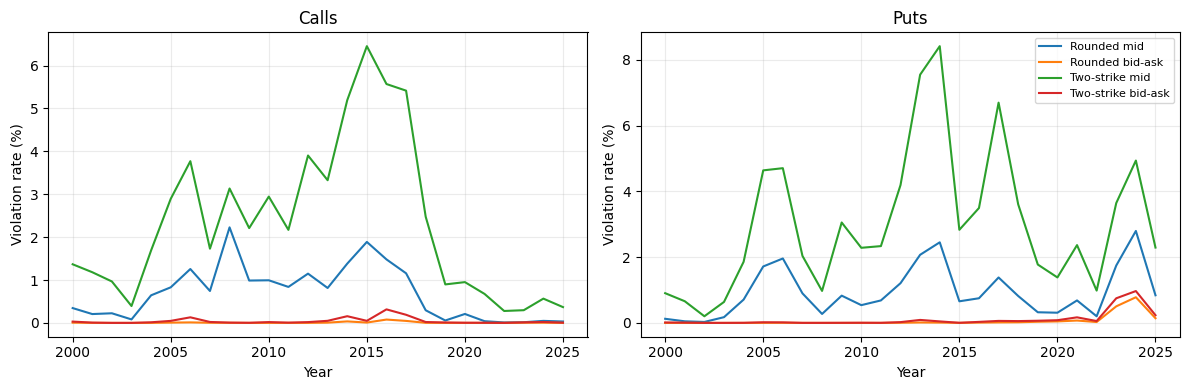

In [10]:
test_labels = {
    "rounded_mid": "Rounded mid",
    "rounded_bid_ask_robust": "Rounded bid-ask",
    "two_strike_mid": "Two-strike mid",
    "two_strike_bid_ask_robust": "Two-strike bid-ask",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, rate_column, title in zip(
    axes,
    ["call_violation_rate", "put_violation_rate"],
    ["Calls", "Puts"],
):
    for run_name, label in test_labels.items():
        rows = paper_checks_year.filter(
            pl.col("run_name") == run_name
        ).sort("year")
        ax.plot(rows["year"], 100 * rows[rate_column], label=label)

    ax.set(title=title, xlabel="Year", ylabel="Violation rate (%)")
    ax.grid(alpha=0.25)

axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "paper_checks_by_year.png", dpi=150)
plt.show()


## 6. Calendar monotonicity

An option should not become cheaper simply because its maturity is extended,
after the comparison has been put on the same forward-moneyness basis. The
calendar check asks how many TP2/RR2 violations also fail this simpler
condition.

`calendar_violation_share` is the share that also fail calendar monotonicity.
`calendar_consistent_share` is the share that pass it, so their TP2/RR2 failure
cannot be reduced to that ordinary calendar failure.


In [11]:
calendar_table = calendar.with_columns(
    (100 * pl.col("calendar_violation_share"))
    .round(2).alias("calendar_failure_percent"),
    (100 * pl.col("calendar_consistent_share"))
    .round(2).alias("calendar_consistent_percent"),
)

display(calendar_table)
display(calendar_moneyness)


cp_flag,total_violations,calendar_testable,calendar_not_testable,calendar_violations,calendar_consistent_violations,fails_at_k1,fails_at_k2,calendar_violation_share,calendar_consistent_share,calendar_not_testable_share,calendar_failure_percent,calendar_consistent_percent
str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""C""",1940008,1935648,4360,97102,1838546,11047,96964,0.050165,0.949835,0.002247,5.02,94.98
"""P""",36759885,36638456,121429,147995,36490461,147841,52499,0.004039,0.995961,0.003303,0.4,99.6


cp_flag,moneyness_region,total_violations,calendar_testable,calendar_not_testable,calendar_violations,calendar_consistent_violations,fails_at_k1,fails_at_k2,calendar_violation_share,calendar_consistent_share,calendar_not_testable_share
str,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64
"""C""","""both_itm""",9862,9785,77,1441,8344,711,1441,0.147266,0.852734,0.007808
"""C""","""both_otm""",1892581,1890101,2480,69947,1820154,6501,69852,0.037007,0.962993,0.00131
"""C""","""crosses_forward""",37565,35762,1803,25714,10048,3835,25671,0.719031,0.280969,0.047997
"""P""","""both_itm""",34022,34022,0,19439,14583,19435,14711,0.571366,0.428634,0.0
"""P""","""both_otm""",36655812,36537930,117882,89419,36448511,89311,18068,0.002447,0.997553,0.003216
"""P""","""crosses_forward""",70051,66504,3547,39137,27367,39095,19720,0.588491,0.411509,0.050635


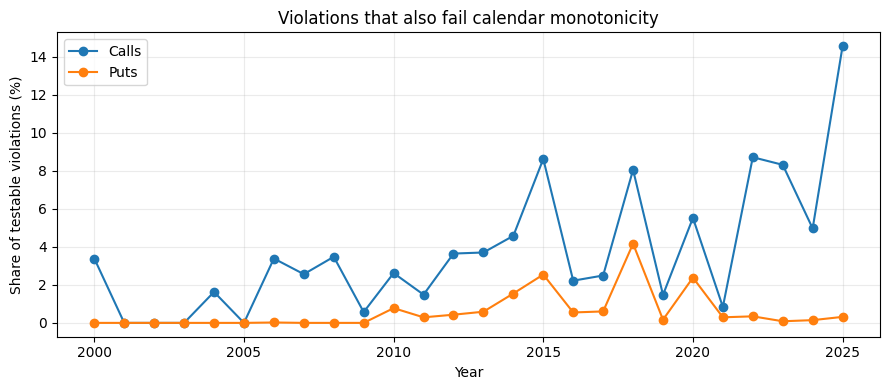

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

for option_type, label in [("C", "Calls"), ("P", "Puts")]:
    rows = calendar_year.filter(
        pl.col("cp_flag") == option_type
    ).sort("year")
    ax.plot(
        rows["year"],
        100 * rows["calendar_violation_share"],
        marker="o",
        label=label,
    )

ax.set(
    xlabel="Year",
    ylabel="Share of testable violations (%)",
    title="Violations that also fail calendar monotonicity",
)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "calendar_monotonicity_check_by_year.png", dpi=150)
plt.show()


## 7. Duration of a violation

A **violation episode** begins when a specific comparison first violates. It
is called corrected only after the same comparison is later observed passing
the test. If required quotes disappear, the episode enters an observability
gap rather than being treated as corrected.

The first table gives all final outcomes. The second calculation reports the
median correction time and the share corrected within five trading days,
conditional on correction eventually being observed.


sample,cp_flag,liquidity,outcome,count,share
str,str,str,str,i64,f64
"""full""","""C""","""all""","""corrected""",757773,0.520343
"""full""","""C""","""all""","""expired_unresolved_after_gap""",656706,0.450943
"""full""","""C""","""all""","""expired_while_violating""",41701,0.028635
"""full""","""C""","""all""","""sample_ended""",114,0.000078
"""full""","""P""","""all""","""corrected""",8817010,0.357306
"""full""","""P""","""all""","""expired_unresolved_after_gap""",14935549,0.605258
"""full""","""P""","""all""","""expired_while_violating""",783855,0.031765
"""full""","""P""","""all""","""sample_ended""",139927,0.00567


cp_flag,median_correction_days,corrected_within_5_days
str,i64,f64
"""C""",2,0.871472
"""P""",2,0.903158


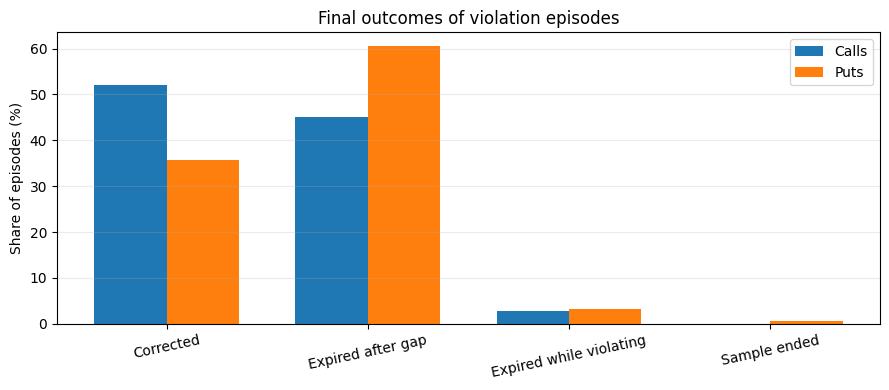

In [13]:
full_duration = duration.filter(pl.col("sample") == "full")
display(full_duration)

correction_rows = []

for option_type in ["C", "P"]:
    corrected = (
        duration_distribution
        .filter(
            (pl.col("cp_flag") == option_type)
            & (pl.col("outcome") == "corrected")
        )
        .sort("trading_days")
    )

    total_corrected = corrected["count"].sum()

    # Walk through the ordered distribution until half the corrected episodes
    # have been reached. This is the conditional median correction time.
    running_count = 0
    median_days = None
    for row in corrected.iter_rows(named=True):
        running_count += row["count"]
        if running_count >= total_corrected / 2:
            median_days = row["trading_days"]
            break

    corrected_in_five_days = (
        corrected
        .filter(pl.col("trading_days") <= 5)["count"]
        .sum()
        / total_corrected
    )

    correction_rows.append({
        "cp_flag": option_type,
        "median_correction_days": median_days,
        "corrected_within_5_days": corrected_in_five_days,
    })

display(pl.DataFrame(correction_rows))

# Plot the four possible final outcomes for calls and puts.
outcomes = [
    "corrected",
    "expired_unresolved_after_gap",
    "expired_while_violating",
    "sample_ended",
]
outcome_labels = [
    "Corrected",
    "Expired after gap",
    "Expired while violating",
    "Sample ended",
]

x = np.arange(len(outcomes))
fig, ax = plt.subplots(figsize=(9, 4))

for offset, option_type, label in [
    (-0.18, "C", "Calls"),
    (0.18, "P", "Puts"),
]:
    values = [
        100 * full_duration.filter(
            (pl.col("cp_flag") == option_type)
            & (pl.col("outcome") == outcome)
        )["share"][0]
        for outcome in outcomes
    ]
    ax.bar(x + offset, values, width=0.36, label=label)

ax.set_xticks(x, outcome_labels, rotation=12)
ax.set(
    ylabel="Share of episodes (%)",
    title="Final outcomes of violation episodes",
)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "targeted_duration_final_outcomes.png", dpi=150)
plt.show()


### Path after the first violation

The persistence curves follow the same episodes for 30 trading days after
their start. At each horizon they separate confirmed correction, expiry after
an observability gap and expiry while the comparison is still violating.
These are cumulative shares of the original episode cohort.


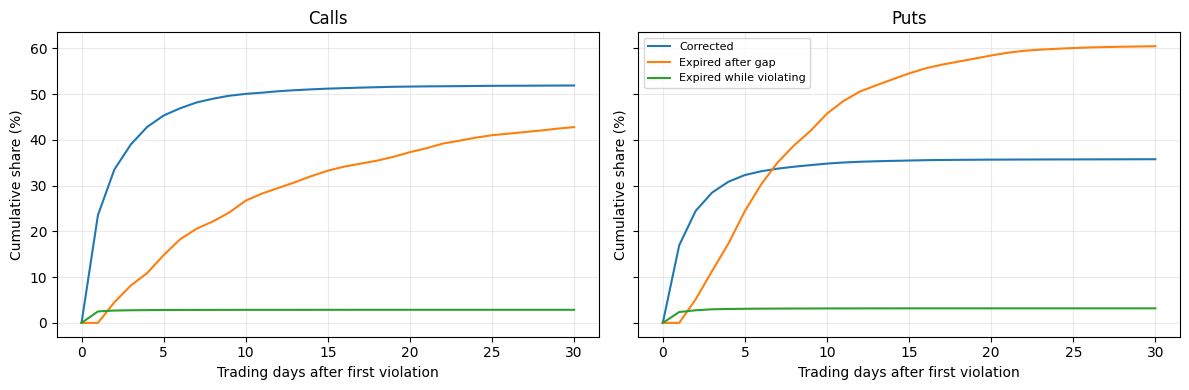

In [14]:
probability_columns = [
    ("confirmed_correction_probability", "Corrected"),
    ("expired_unresolved_probability", "Expired after gap"),
    ("expired_while_violating_probability", "Expired while violating"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, option_type, title in zip(axes, ["C", "P"], ["Calls", "Puts"]):
    rows = (
        persistence
        .filter(
            (pl.col("sample") == "full")
            & (pl.col("liquidity") == "all")
            & (pl.col("cp_flag") == option_type)
            & (pl.col("trading_days_after_start") <= 30)
        )
        .sort("trading_days_after_start")
    )

    for column, label in probability_columns:
        ax.plot(
            rows["trading_days_after_start"],
            100 * rows[column],
            label=label,
        )

    ax.set(
        title=title,
        xlabel="Trading days after first violation",
        ylabel="Cumulative share (%)",
    )
    ax.grid(alpha=0.25)

axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "targeted_duration_persistence.png", dpi=150)
plt.show()


### What happens after a quote gap?

This final table and plot use only episodes that lose at least one required
quote. `ever_reappeared` records whether the comparison later becomes
observable while still violating. The stacked bars therefore distinguish a
genuine observed correction from an episode that simply disappeared from the
data.


sample,cp_flag,liquidity,ever_reappeared,outcome,count,share_of_gap_episodes
str,str,str,bool,str,i64,f64
"""full""","""C""","""all""",false,"""corrected""",306448,0.301364
"""full""","""C""","""all""",false,"""expired_unresolved_after_gap""",585779,0.576061
"""full""","""C""","""all""",false,"""sample_ended""",101,0.000099
"""full""","""C""","""all""",true,"""corrected""",51908,0.051047
"""full""","""C""","""all""",true,"""expired_unresolved_after_gap""",70927,0.06975
…,…,…,…,…,…,…
"""full""","""P""","""all""",false,"""sample_ended""",70839,0.003768
"""full""","""P""","""all""",true,"""corrected""",776022,0.041275
"""full""","""P""","""all""",true,"""expired_unresolved_after_gap""",2009450,0.106878


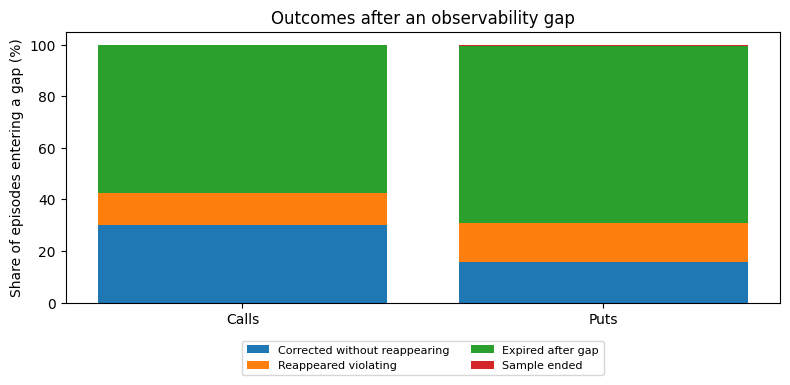

In [15]:
full_gap = gap_outcomes.filter(
    (pl.col("sample") == "full")
    & (pl.col("liquidity") == "all")
)
display(full_gap)

gap_categories = [
    (
        "Corrected without reappearing",
        (~pl.col("ever_reappeared")) & (pl.col("outcome") == "corrected"),
    ),
    ("Reappeared violating", pl.col("ever_reappeared")),
    (
        "Expired after gap",
        (~pl.col("ever_reappeared"))
        & (pl.col("outcome") == "expired_unresolved_after_gap"),
    ),
    (
        "Sample ended",
        (~pl.col("ever_reappeared")) & (pl.col("outcome") == "sample_ended"),
    ),
]

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(2)

for label, category_filter in gap_categories:
    values = []
    for option_type in ["C", "P"]:
        share = full_gap.filter(
            (pl.col("cp_flag") == option_type) & category_filter
        )["share_of_gap_episodes"].sum()
        values.append(100 * share)

    ax.bar(["Calls", "Puts"], values, bottom=bottom, label=label)
    bottom += np.array(values)

ax.set(
    ylabel="Share of episodes entering a gap (%)",
    title="Outcomes after an observability gap",
)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)

fig.tight_layout()
fig.savefig(FIGURES / "targeted_gap_outcomes.png", dpi=150)
plt.show()


## Reading the notebook output

The notebook has reproduced descriptive evidence, not a trading return. A
high midpoint violation rate does not by itself imply an executable profit:
the bid-ask test, quote-quality tables and Chapter 5 backtests address that
separate question.
